# Module 2 Mini Project — Advanced EDA & Insights

**In plain English:** project 2 already cleaned up the messy loan-application
data. This notebook doesn't clean anything new — it digs into that same
clean data more deeply, with richer charts, to find genuinely interesting
patterns worth telling someone about. The end result of this project is a
short slide-style deck (`INSIGHTS_DECK.md`) that presents 5 findings on their
own, chart + one sentence each, without needing this notebook at all.


In [1]:
import sys
sys.path.append("../../02-module2-case-study-preprocessing/src")
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pipeline as pl       # reused from project 2 -- no re-cleaning here
import plotting as pt       # this project's shared chart-styling helpers

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Reuse the cleaned dataset from project 2

We call the *same* `load_raw()` + `clean()` + `encode_and_scale()` functions
project 2 built, so there's no duplicate cleaning logic anywhere. We
deliberately skip project 2's last step (`select_features`, which trims down
to only 9 columns) because a richer story benefits from having more columns
to explore -- income, gender, self-employment and so on -- even though most
of them turned out to be weak *predictors* in project 2.

In [2]:
raw = pl.load_raw()
cleaned = pl.clean(raw)
df = pl.encode_and_scale(cleaned)
df.shape

(614, 15)

## 2. Univariate EDA (one variable at a time)

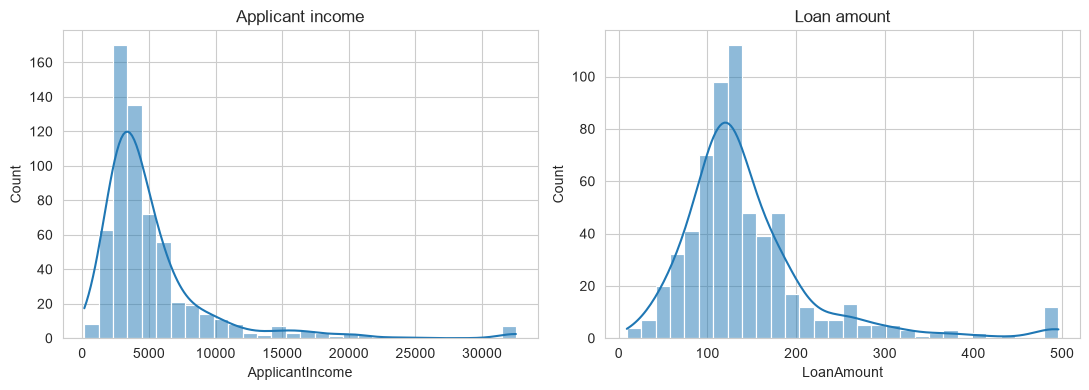

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(cleaned["ApplicantIncome"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Applicant income")
sns.histplot(cleaned["LoanAmount"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Loan amount")
plt.tight_layout()
plt.show()

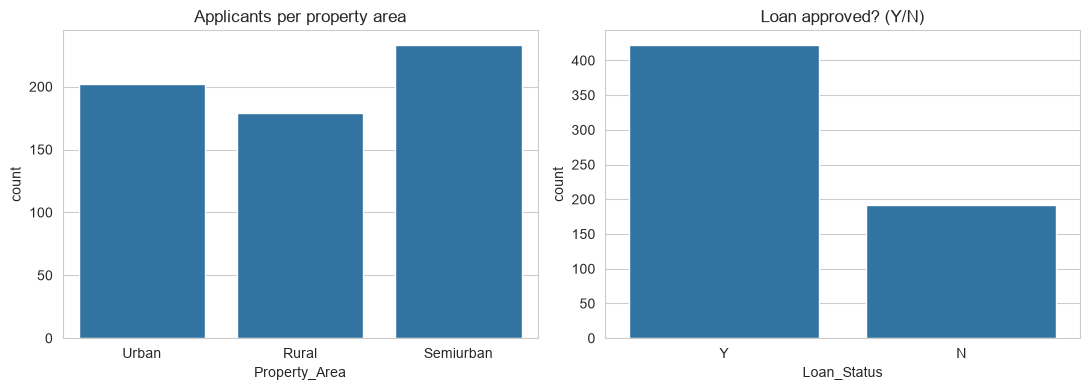

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="Property_Area", data=cleaned, ax=axes[0])
axes[0].set_title("Applicants per property area")
sns.countplot(x="Loan_Status", data=cleaned, ax=axes[1])
axes[1].set_title("Loan approved? (Y/N)")
plt.tight_layout()
plt.show()

## 3. Bivariate / advanced visualization -- heatmap and pairplot

A correlation heatmap across every encoded column, and a pairplot across the
handful of columns most relevant to the approval decision, coloured by
whether the loan was approved.

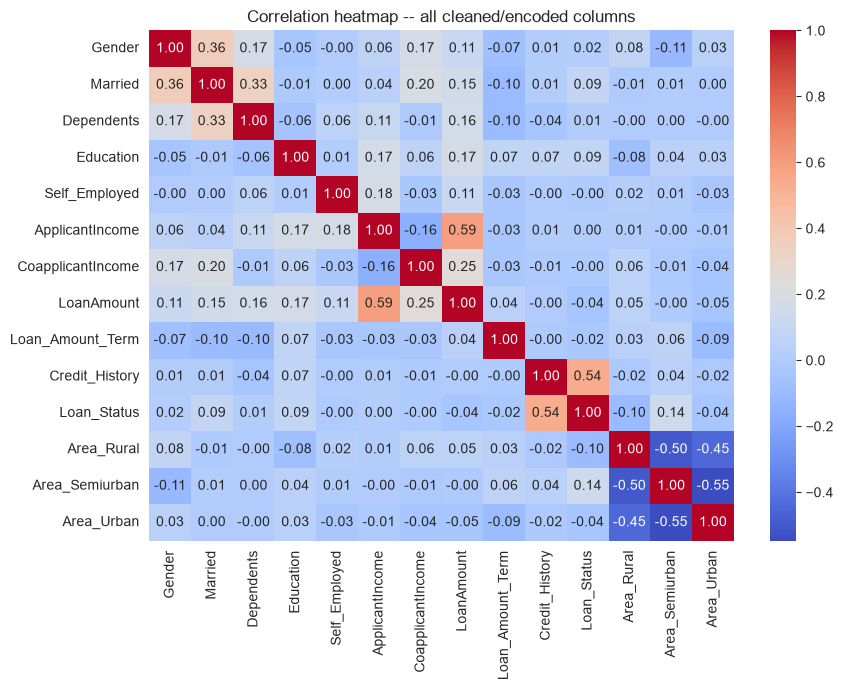

In [5]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.drop(columns=["Loan_ID"]).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap -- all cleaned/encoded columns")
plt.tight_layout()
plt.show()

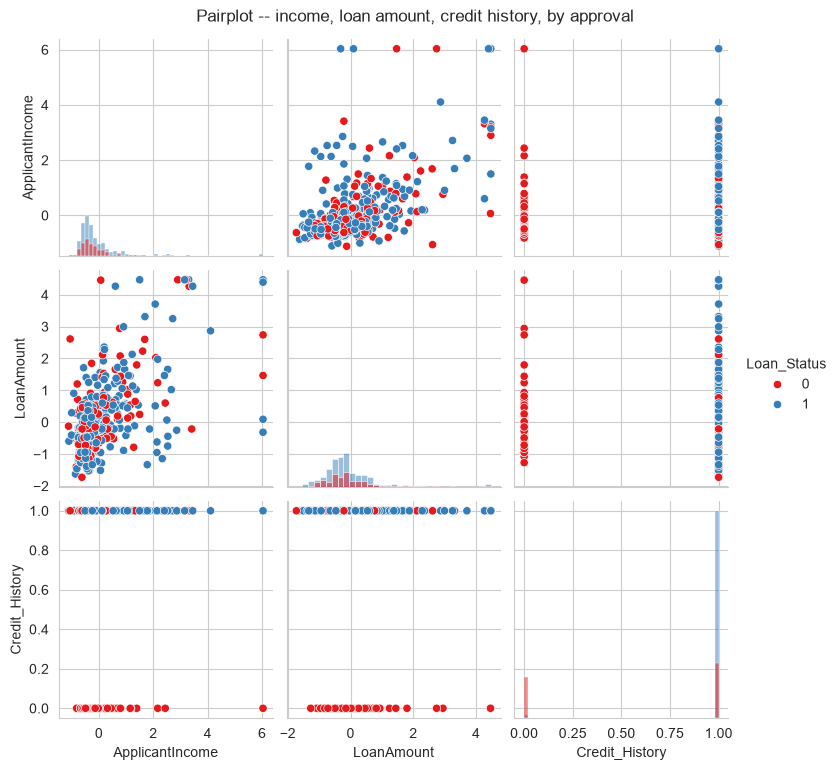

In [6]:
pairplot_cols = ["ApplicantIncome", "LoanAmount", "Credit_History", "Loan_Status"]
sns.pairplot(df[pairplot_cols], hue="Loan_Status", diag_kind="hist", palette="Set1")
plt.suptitle("Pairplot -- income, loan amount, credit history, by approval", y=1.02)
plt.show()

## 4. Five findings worth telling someone about

Each one gets its own chart, saved into `assets/` so `INSIGHTS_DECK.md` can
show it without re-running any code.

### Finding 1 -- Credit history dominates the approval decision
Almost nothing else in this dataset comes close.

Saved chart -> C:\Users\neeha\OneDrive\Desktop\Gray Matter Technologies\GrayMatterTechnologies\03-module2-mini-project-eda-insights\assets\finding1_credit_history.png


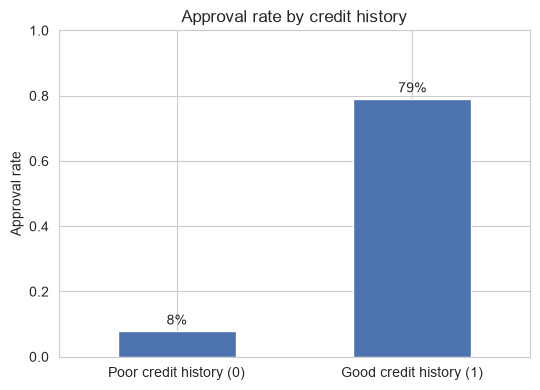

In [7]:
ch_rates = cleaned.assign(Approved=(cleaned["Loan_Status"] == "Y").astype(int)) \
    .groupby("Credit_History")["Approved"].mean()
ch_rates.index = ["Poor credit history (0)", "Good credit history (1)"]
pt.approval_rate_bar(ch_rates, "Approval rate by credit history", "", "finding1_credit_history.png")
plt.show()

**Takeaway:** applicants with a good credit history are approved about **79%**
of the time, versus just **8%** for applicants with a poor one -- a ~10x gap,
by far the single biggest factor in this data.

### Finding 2 -- Where you live matters more than expected
Semiurban applicants are approved noticeably more often than urban *or* rural applicants.

Saved chart -> C:\Users\neeha\OneDrive\Desktop\Gray Matter Technologies\GrayMatterTechnologies\03-module2-mini-project-eda-insights\assets\finding2_property_area.png


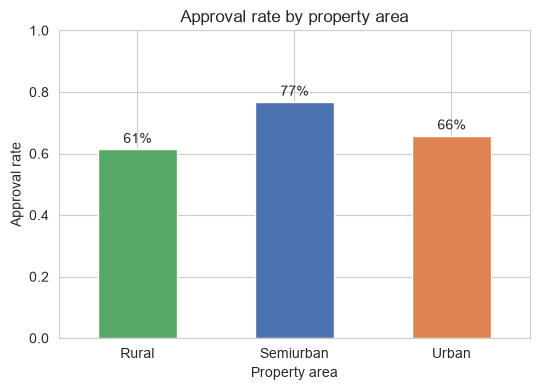

In [8]:
area_rates = cleaned.assign(Approved=(cleaned["Loan_Status"] == "Y").astype(int)) \
    .groupby("Property_Area")["Approved"].mean().reindex(["Rural", "Semiurban", "Urban"])
pt.approval_rate_bar(area_rates, "Approval rate by property area", "Property area",
                      "finding2_property_area.png", palette=["#55A868", "#4C72B0", "#DD8452"])
plt.show()

**Takeaway:** semiurban applicants are approved about **77%** of the time,
versus **66%** for urban and **61%** for rural applicants -- an easy pattern to
miss if you assumed "urban = best odds."


### Finding 3 -- Married applicants get approved more often than single applicants

Saved chart -> C:\Users\neeha\OneDrive\Desktop\Gray Matter Technologies\GrayMatterTechnologies\03-module2-mini-project-eda-insights\assets\finding3_married.png


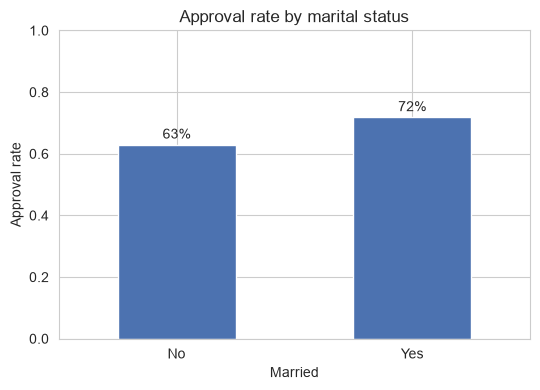

In [9]:
married_rates = cleaned.assign(Approved=(cleaned["Loan_Status"] == "Y").astype(int)) \
    .groupby("Married")["Approved"].mean()
pt.approval_rate_bar(married_rates, "Approval rate by marital status", "Married",
                      "finding3_married.png")
plt.show()

**Takeaway:** married applicants are approved about **72%** of the time versus
**63%** for unmarried applicants -- a real, if smaller, gap.

### Finding 4 -- Self-employed applicants ask for bigger loans, without it costing them approval odds

Saved chart -> C:\Users\neeha\OneDrive\Desktop\Gray Matter Technologies\GrayMatterTechnologies\03-module2-mini-project-eda-insights\assets\finding4_self_employed_loan_amount.png


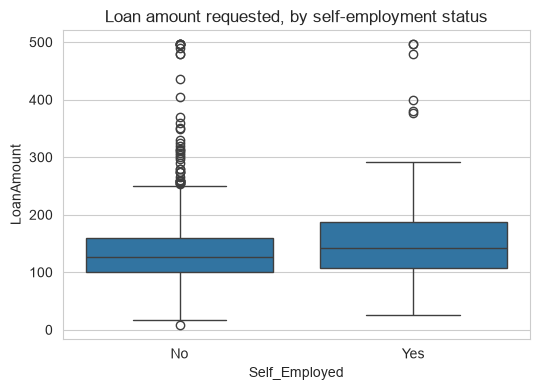

Approval rate by self-employment:
Self_Employed
No     0.687970
Yes    0.682927
Name: Approved, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4))
sns.boxplot(x="Self_Employed", y="LoanAmount", data=cleaned, ax=ax)
ax.set_title("Loan amount requested, by self-employment status")
plt.tight_layout()
pt.save(fig, "finding4_self_employed_loan_amount.png")
plt.show()

se_rates = cleaned.assign(Approved=(cleaned["Loan_Status"] == "Y").astype(int)) \
    .groupby("Self_Employed")["Approved"].mean()
print("Approval rate by self-employment:")
print(se_rates)

**Takeaway:** self-employed applicants request bigger loans on average
(~167k vs ~141k) -- yet their approval rate is nearly identical to
salaried applicants. Asking for more money, by itself, doesn't seem to hurt
your odds here.

### Finding 5 -- Income barely matters, even though it varies a lot by education

Saved chart -> C:\Users\neeha\OneDrive\Desktop\Gray Matter Technologies\GrayMatterTechnologies\03-module2-mini-project-eda-insights\assets\finding5_education_income.png


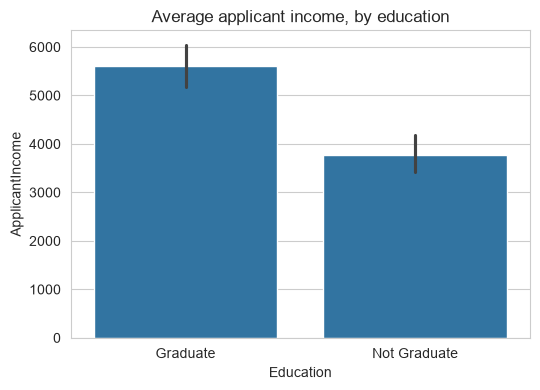

Correlation between ApplicantIncome and Loan_Status: 0.003


In [11]:
fig, ax = plt.subplots(figsize=(5.5, 4))
sns.barplot(x="Education", y="ApplicantIncome", data=cleaned, ax=ax, estimator=np.mean)
ax.set_title("Average applicant income, by education")
plt.tight_layout()
pt.save(fig, "finding5_education_income.png")
plt.show()

print("Correlation between ApplicantIncome and Loan_Status:",
      round(df[["ApplicantIncome", "Loan_Status"]].corr().iloc[0, 1], 3))

**Takeaway:** graduates earn about **48% more** on average than
non-graduates (~5,609 vs ~3,777) -- but income has almost **zero** correlation
(0.003) with whether the loan gets approved. More money doesn't buy a better
approval chance in this dataset; a good credit history does.

## Summary

These five findings -- credit history, property area, marital status,
self-employment/loan size, and income/education -- are packaged as a short,
standalone deck in **`INSIGHTS_DECK.md`** in this project's folder. That deck
is meant to be readable on its own, without opening this notebook.
